# Load Test — /sync endpoint

**Objectif** : identifier le point de saturation du serveur Python en envoyant des rafales croissantes de requêtes `/sync` (open-loop, charge concurrente).

**Protocole** :
- Chaque palier envoie `N` req/s pendant `PALIER_DURATION_S` secondes, puis attend que toutes les requêtes en vol aient répondu (drain).
- Métrique d'arrêt : **p95 > 20 s** (moyenne glissante sur le palier courant).
- Population source : `toulouse_population_5000.json`, mélangée avec `RANDOM_SEED`.
- Chaque requête contient `PEOPLE_PER_REQUEST` agents idle sélectionnés aléatoirement.

> **Prérequis** : le serveur doit être démarré et initialisé (`/init` appelé par GAMA) avant d'exécuter ce notebook.

In [1]:
import asyncio
import json
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import aiohttp
from pathlib import Path

In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────
BASE_URL            = "http://localhost:8002"   # contrôleur de simulation (port 8002)
POPULATION_FILE     = Path("../../data/eqasim_output/toulouse_population_1000.json")
POPULATION_SIZE     = 1000                      # doit correspondre au fichier ci-dessus

RANDOM_SEED         = 42          # reproductibilité du shuffle
PEOPLE_PER_REQUEST  = 5          # agents idle par requête /sync (réaliste)
PALIER_DURATION_S   = 10          # secondes de tir par palier
REQUEST_TIMEOUT_S   = 10          # timeout par requête (aiohttp)
WARMUP_REQUESTS     = 5           # requêtes de chauffe ignorées des métriques
STOP_P95_S          = 180.0        # seuil p95 déclenchant l'arrêt
LIMIT_CONSECUTIVE_PALIER = 7       # nombre de paliers consécutifs au-delà du seuil pour arrêter

# Paliers : 1, 2, 3, ... 50 req/s of PEOPLE_PER_REQUEST agents
RATE_STEPS          = list(range(1, 120, 3))

# Timestamp simulé fixe (cohérent avec la population toulouse)
SIM_TIMESTAMP       = 1_775_800_000

In [3]:
# ── Chargement et préparation de la population ────────────────────────────────
raw = json.loads(POPULATION_FILE.read_text())

# Extraire les paires (person_id, location) utilisables comme idle_people
people_pool = []
for p in raw:
    pid = p["person_id"]
    home = p["identity"]["home"]
    people_pool.append({
        "person_id": pid,
        "location": {"lon": home["lon"], "lat": home["lat"], "public_transport": home.get("public_transport", False)}
    })

rng = random.Random(RANDOM_SEED)
rng.shuffle(people_pool)

print(f"Population chargée : {len(people_pool)} personnes")
print(f"Exemple : {people_pool[0]}")

Population chargée : 941 personnes
Exemple : {'person_id': '1187666', 'location': {'lon': 1.3852843512308957, 'lat': 43.57662788346354, 'public_transport': True}}


In [4]:
# ── Fonctions utilitaires ─────────────────────────────────────────────────────

def make_sync_payload(sample: list[dict]) -> dict:
    return {"timestamp": SIM_TIMESTAMP, "idle_people": sample}


async def send_sync(session: aiohttp.ClientSession, sample: list[dict]) -> dict:
    payload = make_sync_payload(sample)
    t0 = time.perf_counter()
    try:
        async with session.post(
            f"{BASE_URL}/sync",
            json=payload,
            timeout=aiohttp.ClientTimeout(total=REQUEST_TIMEOUT_S),
        ) as resp:
            body = await resp.json(content_type=None)
            latency = time.perf_counter() - t0
            app_error = None
            if resp.status >= 400:
                app_error = f"http_{resp.status}"
            elif isinstance(body, dict) and not body.get("success", True):
                app_error = body.get("error") or "app_error"
            return {"latency": latency, "status": resp.status, "error": app_error}
    except asyncio.TimeoutError:
        return {"latency": REQUEST_TIMEOUT_S, "status": None, "error": "timeout"}
    except Exception as e:
        return {"latency": time.perf_counter() - t0, "status": None, "error": str(e)[:80]}


async def get_queue_depth(session: aiohttp.ClientSession) -> int:
    """Return current scheduling_in_progress count."""
    try:
        async with session.get(
            f"{BASE_URL}/test/queue_depth",
            timeout=aiohttp.ClientTimeout(total=5),
        ) as resp:
            body = await resp.json(content_type=None)
            return body.get("scheduling_in_progress", 0)
    except Exception:
        return -1


async def wait_queue_empty(session: aiohttp.ClientSession,
                           poll_interval: float = 0.5,
                           timeout: float = 120.0) -> float:
    """Poll until scheduling_in_progress=0. Returns elapsed seconds."""
    t0 = time.perf_counter()
    deadline = t0 + timeout
    while time.perf_counter() < deadline:
        depth = await get_queue_depth(session)
        if depth == 0:
            return time.perf_counter() - t0
        await asyncio.sleep(poll_interval)
    return time.perf_counter() - t0  # timeout reached


async def run_palier(
    session: aiohttp.ClientSession,
    rate: float,
    duration: float,
    pool: list[dict],
    batch_size: int,
    rng_state: random.Random,
) -> list[dict]:
    """Open-loop : fire at `rate` req/s for `duration` seconds, drain HTTP responses."""
    interval = 1.0 / rate
    tasks = []
    deadline = time.perf_counter() + duration
    while time.perf_counter() < deadline:
        sample = rng_state.choices(pool, k=batch_size)
        tasks.append(asyncio.create_task(send_sync(session, sample)))
        try:
            await asyncio.sleep(interval)
        except asyncio.CancelledError:
            break
    results = await asyncio.gather(*tasks, return_exceptions=True)
    return [r for r in results if isinstance(r, dict)]


def compute_metrics(results: list[dict]) -> dict:
    latencies = [r["latency"] for r in results]
    errors = [r for r in results if r["error"] is not None]
    n = len(results)
    n_err = len(errors)
    lat = np.array(latencies) if latencies else np.array([0.0])
    error_types = {}
    for r in errors:
        k = r["error"]
        error_types[k] = error_types.get(k, 0) + 1
    return {
        "n_requests": n,
        "n_errors": n_err,
        "error_rate": n_err / n if n else 0.0,
        "error_types": error_types,
        "http_p50_s": float(np.percentile(lat, 50)),
        "http_p95_s": float(np.percentile(lat, 95)),
    }

In [5]:
# ── Initialisation du scénario (mode test, sans GAMA) ────────────────────────
async def test_init():
    async with aiohttp.ClientSession() as session:
        print(f"Initialisation du scénario via /test/init (population_size={POPULATION_SIZE})...")
        async with session.post(
            f"{BASE_URL}/test/init",
            params={"population_size": POPULATION_SIZE, "timestamp": SIM_TIMESTAMP},
            timeout=aiohttp.ClientTimeout(total=300),
        ) as resp:
            body = await resp.json(content_type=None)
            if body.get("success"):
                d = body.get("data", {})
                print(f"  ✓ Scénario prêt — {d.get('num_people')} agents ({d.get('population_file')})")
                return True
            else:
                print(f"  ✗ Échec HTTP {resp.status} : {body.get('error') or body.get('detail')}")
                return False

scenario_ready = await test_init()

# ── Warmup ────────────────────────────────────────────────────────────────────
async def warmup(session: aiohttp.ClientSession):
    if not scenario_ready:
        print("Warmup ignoré (scénario non initialisé).")
        return
    print(f"Warmup : {WARMUP_REQUESTS} requêtes...")
    tasks = [
        send_sync(session, rng.choices(people_pool, k=PEOPLE_PER_REQUEST))
        for _ in range(WARMUP_REQUESTS)
    ]
    results = await asyncio.gather(*tasks)
    ok = sum(1 for r in results if r["error"] is None)
    print(f"Warmup terminé : {ok}/{WARMUP_REQUESTS} OK")

Initialisation du scénario via /test/init (population_size=1000)...
  ✓ Scénario prêt — 908 agents (/app/experiments/2026-05-18_16_25/population_1000.json)


In [6]:
# ── Diagnostic : une seule requête pour vérifier la connectivité ──────────────
async def diagnose():
    async with aiohttp.ClientSession() as session:
        # Health check
        try:
            async with session.get(f"{BASE_URL}/", timeout=aiohttp.ClientTimeout(total=5)) as r:
                print(f"GET /        → HTTP {r.status}")
        except Exception as e:
            print(f"GET /        → ERREUR : {e}")

        # Test /sync avec 1 personne
        try:
            sample = [people_pool[0]]
            result = await send_sync(session, sample)
            status_str = f"HTTP {result['status']}" if result['status'] else "pas de réponse"
            err_str = f"  ⚠  {result['error']}" if result['error'] else "  ✓ OK"
            print(f"POST /sync   → {status_str} | latence {result['latency']*1000:.0f}ms{err_str}")
        except Exception as e:
            print(f"POST /sync   → EXCEPTION : {e}")

await diagnose()

GET /        → HTTP 200
POST /sync   → HTTP 200 | latence 332ms  ✓ OK


In [7]:
# ── Load test principal ───────────────────────────────────────────────────────
# Métrique clé : pipeline_total_s = T_start (premier idle_people mis à jour)
#                                 → queue_depth=0 (dernier choix LLM reçu)
records = []
rng_run = random.Random(RANDOM_SEED)

connector = aiohttp.TCPConnector(limit=0)

async def main_load_test():
    nb_consecutive_over = 0
    async with aiohttp.ClientSession(connector=connector) as session:
        await warmup(session)
        await wait_queue_empty(session)  # état propre après warmup
        print()

        for rate in RATE_STEPS:
            # Attendre que le palier précédent soit vidé
            residual = await get_queue_depth(session)
            if residual > 0:
                print(f"  [queue résiduelle: {residual} agents, attente...]")
                await wait_queue_empty(session)

            T_start = time.perf_counter()
            sync_results = await run_palier(
                session, rate, PALIER_DURATION_S,
                people_pool, PEOPLE_PER_REQUEST, rng_run
            )
            T_fire_end = time.perf_counter()

            # Attendre que tous les choix LLM/OTP soient revenus
            drain_s = await wait_queue_empty(session, timeout=STOP_P95_S * 2)
            T_pipeline_end = time.perf_counter()

            m = compute_metrics(sync_results)
            m["rate_target"]       = rate
            m["http_fire_s"]       = T_fire_end - T_start
            m["pipeline_drain_s"]  = drain_s
            m["pipeline_total_s"]  = T_pipeline_end - T_start
            m["nb_agents"]         = m['n_requests']*PEOPLE_PER_REQUEST
            records.append(m)

            print(
                f"rate={rate:>4} req/s | n={m['n_requests']:>5} | "
                f"nb_agents={m['nb_agents']:>6} | "
                f"pipeline={m['pipeline_total_s']:>6.1f}s "
                f"(tir={m['http_fire_s']:.1f}s  drain={m['pipeline_drain_s']:.1f}s) | "
                f"err={m['error_rate']*100:>5.1f}%"
            )

            if m["pipeline_total_s"] >= STOP_P95_S:
                nb_consecutive_over += 1
                if nb_consecutive_over >= LIMIT_CONSECUTIVE_PALIER:
                    print(f"\n⚠  ARRÊT : pipeline={m['pipeline_total_s']:.1f}s ≥ seuil {STOP_P95_S}s au palier {rate} req/s")
                    break
            else:
                nb_consecutive_over = 0  # reset counter if under threshold

await main_load_test()

Warmup : 5 requêtes...
Warmup terminé : 5/5 OK

rate=   1 req/s | n=   10 | nb_agents=    50 | pipeline= 113.4s (tir=10.0s  drain=103.4s) | err=  0.0%
rate=   4 req/s | n=   40 | nb_agents=   200 | pipeline= 114.4s (tir=10.4s  drain=104.1s) | err=  0.0%
rate=   7 req/s | n=   70 | nb_agents=   350 | pipeline= 115.2s (tir=10.5s  drain=104.7s) | err=  0.0%
rate=  10 req/s | n=   99 | nb_agents=   495 | pipeline= 115.0s (tir=10.8s  drain=104.3s) | err=  0.0%
rate=  13 req/s | n=  128 | nb_agents=   640 | pipeline= 114.9s (tir=10.6s  drain=104.4s) | err=  0.0%
rate=  16 req/s | n=  157 | nb_agents=   785 | pipeline= 114.9s (tir=10.7s  drain=104.2s) | err=  0.0%
rate=  19 req/s | n=  185 | nb_agents=   925 | pipeline= 115.0s (tir=10.6s  drain=104.4s) | err=  0.0%
rate=  22 req/s | n=  213 | nb_agents=  1065 | pipeline= 115.4s (tir=11.0s  drain=104.4s) | err=  0.0%
rate=  25 req/s | n=  244 | nb_agents=  1220 | pipeline= 115.5s (tir=11.0s  drain=104.5s) | err=  0.0%
rate=  28 req/s | n=  273

CancelledError: 

In [ ]:
# ── DataFrame des résultats ───────────────────────────────────────────────────
df = pd.DataFrame(records)
df["error_pct"]         = df["error_rate"] * 100
df["pipeline_total_ms"] = df["pipeline_total_s"] * 1000
df["http_fire_ms"]      = df["http_fire_s"] * 1000
df["pipeline_drain_ms"] = df["pipeline_drain_s"] * 1000

sat_row = df[df["pipeline_total_s"] >= STOP_P95_S]
sat_rate = int(sat_row["rate_target"].iloc[0]) if not sat_row.empty else None
print(f"Point de saturation (pipeline ≥ {STOP_P95_S}s) : {sat_rate} req/s" if sat_rate else "Pas de saturation atteinte.")

df[["rate_target", "n_requests", "http_fire_ms", "pipeline_drain_ms", "pipeline_total_ms", "error_pct"]].round(0)

Point de saturation (pipeline ≥ 180.0s) : 49 req/s


,rate_target,n_requests,http_fire_ms,pipeline_drain_ms,pipeline_total_ms,error_pct
0,1,10,10011.0,1023.0,11034.0,20.0
1,2,20,10024.0,6059.0,16084.0,0.0
2,3,30,10035.0,8091.0,18126.0,0.0
3,4,40,10045.0,16691.0,26736.0,0.0
4,5,50,10057.0,24899.0,34956.0,0.0
5,6,60,10065.0,20736.0,30801.0,0.0
6,7,70,10080.0,32449.0,42529.0,0.0
7,8,80,10089.0,90011.0,100101.0,0.0
8,9,90,10094.0,27904.0,37998.0,0.0
9,10,100,10101.0,37098.0,47199.0,0.0


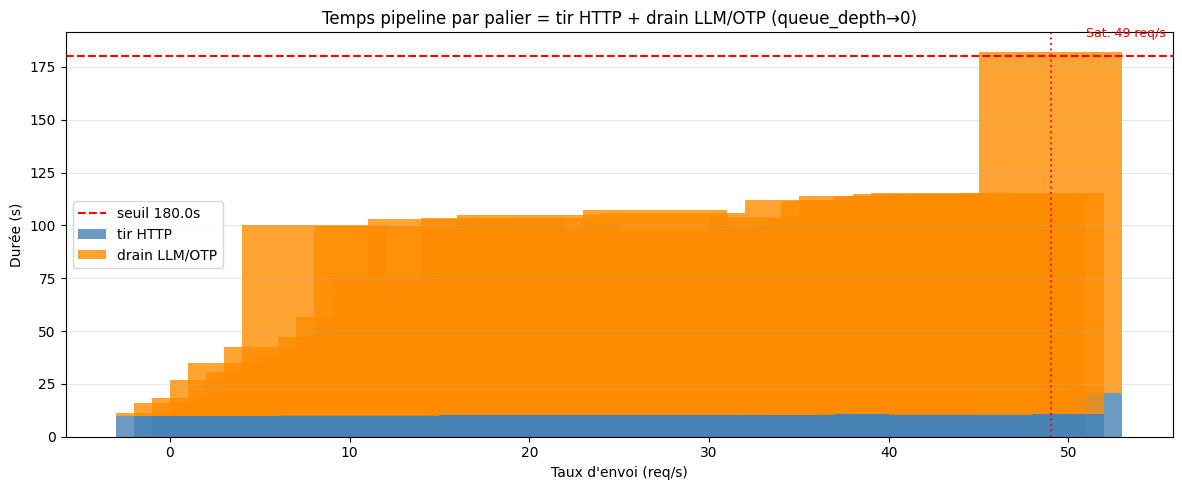

In [ ]:
# ── Visualisation 1 : temps pipeline total (tir + drain LLM/OTP) ─────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(df["rate_target"], df["http_fire_s"],
       width=8, color="steelblue", alpha=0.8, label="tir HTTP")
ax.bar(df["rate_target"], df["pipeline_drain_s"],
       width=8, bottom=df["http_fire_s"], color="darkorange", alpha=0.8, label="drain LLM/OTP")

ax.axhline(STOP_P95_S, color="red", linestyle="--", linewidth=1.5, label=f"seuil {STOP_P95_S}s")

if sat_rate:
    ax.axvline(sat_rate, color="red", linestyle=":", linewidth=1.5, alpha=0.8)
    ax.text(sat_rate + 2, STOP_P95_S * 1.05, f"Sat. {sat_rate} req/s",
            color="red", fontsize=9)

ax.set_xlabel("Taux d'envoi (req/s)")
ax.set_ylabel("Durée (s)")
ax.set_title("Temps pipeline par palier = tir HTTP + drain LLM/OTP (queue_depth→0)")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("load_test_pipeline.png", dpi=150)
plt.show()

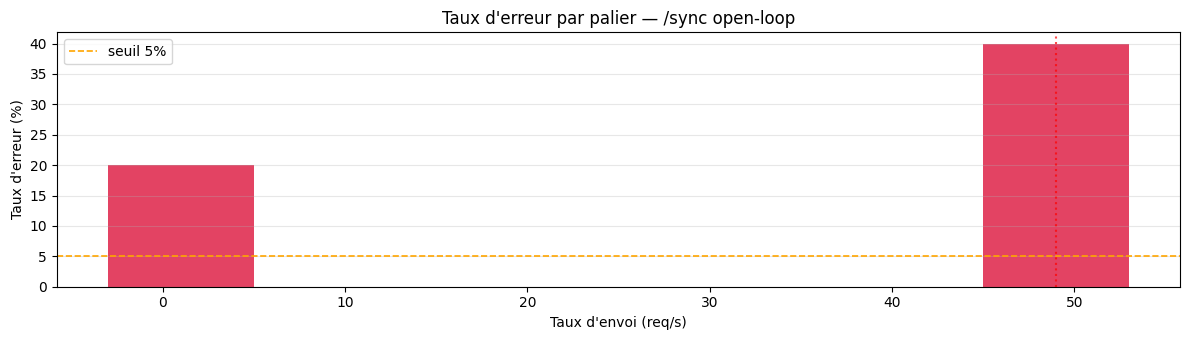

In [ ]:
# ── Visualisation 2 : taux d'erreur par palier ────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 3.5))

colors = ["crimson" if e > 5 else "steelblue" for e in df["error_pct"]]
ax.bar(df["rate_target"], df["error_pct"], width=8, color=colors, alpha=0.8)
ax.axhline(5, color="orange", linestyle="--", linewidth=1.2, label="seuil 5%")

if sat_rate:
    ax.axvline(sat_rate, color="red", linestyle=":", linewidth=1.5, alpha=0.7)

ax.set_xlabel("Taux d'envoi (req/s)")
ax.set_ylabel("Taux d'erreur (%)")
ax.set_title("Taux d'erreur par palier — /sync open-loop")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("load_test_errors.png", dpi=150)
plt.show()

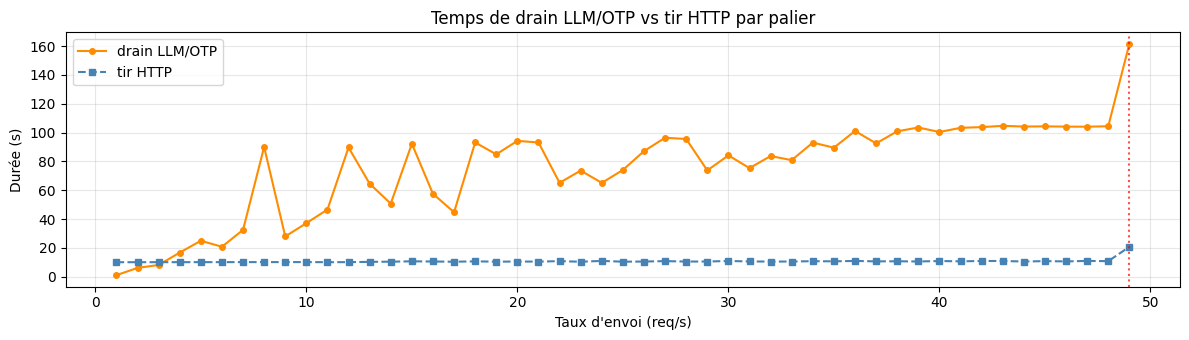

In [ ]:
# ── Visualisation 3 : queue_depth au cours du temps (dernier palier) ──────────
# Graphe indicatif : montre la progression du drain sur le dernier palier mesuré.
# Pour une courbe complète, il faudrait instrumenter le polling en continu.
fig, ax = plt.subplots(figsize=(12, 3.5))

ax.plot(df["rate_target"], df["pipeline_drain_s"],
        marker="o", markersize=4, color="darkorange", label="drain LLM/OTP")
ax.plot(df["rate_target"], df["http_fire_s"],
        marker="s", markersize=4, color="steelblue", label="tir HTTP", linestyle="--")

if sat_rate:
    ax.axvline(sat_rate, color="red", linestyle=":", linewidth=1.5, alpha=0.7)

ax.set_xlabel("Taux d'envoi (req/s)")
ax.set_ylabel("Durée (s)")
ax.set_title("Temps de drain LLM/OTP vs tir HTTP par palier")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("load_test_drain.png", dpi=150)
plt.show()

In [ ]:
# ── Synthèse ─────────────────────────────────────────────────────────────────
print("=" * 70)
print("SYNTHÈSE DU LOAD TEST — /sync open-loop")
print("Métrique : pipeline_total = T_start → queue_depth=0 (LLM/OTP terminés)")
print("=" * 70)
print(f"Population     : {len(people_pool)} personnes  |  {PEOPLE_PER_REQUEST} par requête")
print(f"Durée tir/palier : {PALIER_DURATION_S}s  |  Timeout drain : {STOP_P95_S * 2}s  |  Seuil arrêt : {STOP_P95_S}s")
print()

if sat_rate:
    print(f"  Point de saturation : {sat_rate} req/s (pipeline ≥ {STOP_P95_S}s)")
else:
    last = df.iloc[-1]
    print(f"  Pas de saturation atteinte jusqu'à {int(last['rate_target'])} req/s")

err_row = df[df["error_pct"] > 5]
if not err_row.empty:
    print(f"  Erreurs > 5%         : dès {int(err_row.iloc[0]['rate_target'])} req/s")
else:
    print(f"  Erreurs > 5%         : jamais atteint")

drain_sig = df[df["pipeline_drain_s"] > df["http_fire_s"]]
if not drain_sig.empty:
    print(f"  Drain > tir          : dès {int(drain_sig.iloc[0]['rate_target'])} req/s (LLM/OTP devient goulot)")

print()
print("Tableau complet :")
print(df[["rate_target", "n_requests", "http_fire_s", "pipeline_drain_s",
          "pipeline_total_s", "error_pct"]].round(2).to_string(index=False))

SYNTHÈSE DU LOAD TEST — /sync open-loop
Métrique : pipeline_total = T_start → queue_depth=0 (LLM/OTP terminés)
Population     : 941 personnes  |  5 par requête
Durée tir/palier : 10s  |  Timeout drain : 360.0s  |  Seuil arrêt : 180.0s

  Point de saturation : 49 req/s (pipeline ≥ 180.0s)
  Erreurs > 5%         : dès 1 req/s
  Drain > tir          : dès 4 req/s (LLM/OTP devient goulot)

Tableau complet :
 rate_target  n_requests  http_fire_s  pipeline_drain_s  pipeline_total_s  error_pct
           1          10        10.01              1.02             11.03      20.00
           2          20        10.02              6.06             16.08       0.00
           3          30        10.03              8.09             18.13       0.00
           4          40        10.05             16.69             26.74       0.00
           5          50        10.06             24.90             34.96       0.00
           6          60        10.06             20.74             30.80       0.0

In [ ]:
df.to_csv("load_test_results.csv", index=False)